##  Freeman Chain Code F8 Method for bi level images on Python

## Import Libraries

In [14]:
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

## Upload Image

In [15]:
#ruta = input("Introduce la ruta del GIF: ")
ruta = input("ea")

imagen = Image.open(ruta)
imagen.seek(0)

# Convertimos el GIF a escala de grises
imagen = imagen.convert("L")

# Lo convertimos en matriz NumPy
matriz = np.array(imagen)

print("Tamaño:", matriz.shape)
print("Valores encontrados:", np.unique(matriz))

Tamaño: (361, 324)
Valores encontrados: [  0 255]


## Show Image

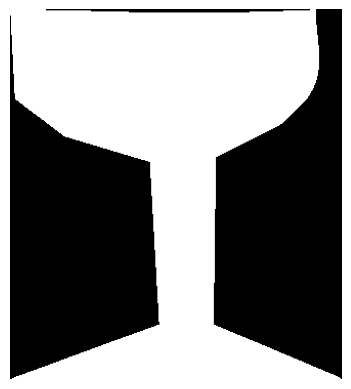

In [16]:
import matplotlib.pyplot as plt

plt.imshow(matriz, cmap="gray")
plt.axis("off")
plt.show()

## Get pixels

In [17]:
def encontrar_inicio(imagen):
    alto, ancho = imagen.shape

    for y in range(alto):
        for x in range(ancho):
            if imagen[y, x] == 255:
                return y, x

inicio = encontrar_inicio(matriz)

print("Inicio:", inicio)

direcciones = {
    0: (0, 1),      # Derecha
    1: (1, 1),      # Abajo-derecha
    2: (1, 0),      # Abajo
    3: (1, -1),     # Abajo-izquierda
    4: (0, -1),     # Izquierda
    5: (-1, -1),    # Arriba-izquierda
    6: (-1, 0),     # Arriba
    7: (-1, 1)      # Arriba-derecha
}



def siguiente_pixel(imagen, actual, direccion_anterior):

    y, x = actual
    alto, ancho = imagen.shape

    # Orden de búsqueda en sentido horario.
    #
    # Primero intentamos girar a la derecha,
    # después continuar recto,
    # después izquierda,
    # finalmente retroceder.
    orden = [
        (direccion_anterior + 6) % 8,
        (direccion_anterior + 7) % 8,
        direccion_anterior,
        (direccion_anterior + 1) % 8,
        (direccion_anterior + 2) % 8,
        (direccion_anterior + 3) % 8,
        (direccion_anterior + 4) % 8,
        (direccion_anterior + 5) % 8
    ]

    for direccion in orden:

        dy, dx = direcciones[direccion]

        nuevo_y = y + dy
        nuevo_x = x + dx

        # Comprobar límites
        if 0 <= nuevo_y < alto and 0 <= nuevo_x < ancho:

            # ¿Es parte del objeto?
            if imagen[nuevo_y, nuevo_x] == 255:

                return (nuevo_y, nuevo_x), direccion

    return None, None

Inicio: (0, 0)


## Test neighbors

In [18]:
direccion_inicial = 0

def obtener_chain_code(imagen, inicio):

    actual = inicio

    # Dirección inicial: derecha
    direccion_anterior = 0

    cadena = []
    recorrido = [inicio]

    alto, ancho = imagen.shape

    # Límite de seguridad para evitar ciclos infinitos
    max_iteraciones = alto * ancho

    for _ in range(max_iteraciones):

        siguiente, direccion = siguiente_pixel(
            imagen,
            actual,
            direccion_anterior
        )

        # No encontramos otro píxel
        if siguiente is None:
            print("No se encontró un siguiente píxel.")
            break

        cadena.append(direccion)
        recorrido.append(siguiente)

        actual = siguiente
        direccion_anterior = direccion

        # Regresamos al inicio
        if actual == inicio and len(cadena) > 1:
            break

    return cadena, recorrido
cadena, recorrido = obtener_chain_code(matriz, inicio)

## Get String

In [19]:
cadena_string = ''.join(map(str, cadena))

print("Chain Code F8:")
print(cadena_string)

print("\nLongitud:", len(cadena_string))

Chain Code F8:
0000000000000000000000000000000000100000000000000000000000000000000000000000001000000000000000000000000000000000000100000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000070000000000000000000000000000000070000000000000000000000000700000222222222222221222222222122222222212222222222222222222222232222232223223232232332323323333333333333333333333333433434343434343434343434343434343434343434343434343434343434343432222222222222222222222222222222222222222222222222232222222222222222222222222222222222222222222222222222222222222222222222232222222222222222222222222222222222222222101010010100101010010101001010010101001010010101001010010101001010100101001010100101001010100101010010100101010010100101010144444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444444

## Show route

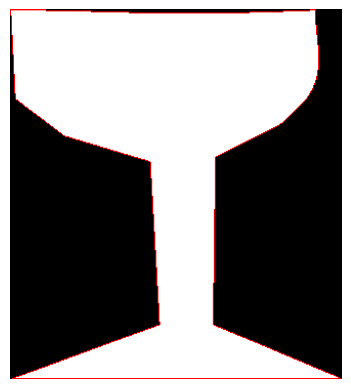

In [20]:
imagen_recorrido = cv2.cvtColor(matriz, cv2.COLOR_GRAY2BGR)

for i in range(len(recorrido) - 1):

    y1, x1 = recorrido[i]
    y2, x2 = recorrido[i + 1]

    cv2.line(
        imagen_recorrido,
        (x1, y1),
        (x2, y2),
        (0, 0, 255),
        1
    )

#plt.figure(figsize=(12, 10))
plt.imshow(cv2.cvtColor(imagen_recorrido, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()